

---

# **ORIGINAL CODE**


---



In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 49.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 31.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
from spacy import displacy
import os
import datetime
#Install spacy and download a language model (if you haven't already) --
#(en_core_web_sm is a small English model, suitable for demonstration)

try:
  nlp = spacy.load("en_core_web_sm")
  print("spaCy model 'en_core_web_sm' loaded successfully.")
except OSError:
  print("Error: 'en_core_web_sm' model not found. Please run 'python -m spacy download en_core_web_sm' in your terminal.")
  exit()


#--- Main execution block ---
if __name__ == "__main__":
  print("\n--- Named Entity Recognition with spacy ---")


  #--- Display available NER entity categories ---
  if 'ner' in nlp.pipe_names:
      ner_labels = nlp.get_pipe('ner').labels
      print("\n--- Available Entity Categories (Labels) ---")
      print(", ".join(sorted(ner_labels)))
  else:
      print("\nNER pipeline component not found in the loaded model.")

  print("\nEnter the text you want to analyze (type 'quit' to exit):")
  output_counter = 0

  while True:
    input_text = input("\nEnter text to process (enter quit to stop): ")

    if input_text.lower() == 'quit':
      break
    elif not input_text.strip():
      print("Invalid input: Please provide a non-empty string for processing.")
      continue

    doc = nlp(input_text)

    print("\n--- Detected Named Entities ---")
    if doc.ents:
      for ent in doc.ents:
        print(f"Text: '{ent.text}' | Label: {ent.label_} ({spacy.explain(ent.label_)})")
        print()
    else:
      print("No named entities detected in the text.")


    #displacy.render(doc, style="ent", jupyter=True)

spaCy model 'en_core_web_sm' loaded successfully.

--- Named Entity Recognition with spacy ---

--- Available Entity Categories (Labels) ---
CARDINAL, DATE, EVENT, FAC, GPE, LANGUAGE, LAW, LOC, MONEY, NORP, ORDINAL, ORG, PERCENT, PERSON, PRODUCT, QUANTITY, TIME, WORK_OF_ART

Enter the text you want to analyze (type 'quit' to exit):

Enter text to process (enter quit to stop): As LeBron James inches closer to scaling the summit of the NBA’s all-time points scoring record, tickets prices at venues where he is likely to get there are going through the roof as well. Tickets for the Los Angeles Lakers versus Oklahoma City Thunder game on February 7 at the Crypto.com Arena are selling for an eye-watering sum of $92,000 (approximately Rs 75 lakh), according to Bleacher Report. This, despite the fact that it’s not a certainty that James will break the record in the Lakers-Thunder game. The Lakers will take on New Orleans Pelicans on February 4, the Milwaukee Bucks on February 9 and the Golden 



---

# **MY TESTING - SMALL SPACY MODEL**


---



In [ ]:
import spacy
from spacy import displacy
import os
import datetime
import csv

# Install spacy and download a language model (if you haven't already) --
# (en_core_web_sm is a small English model, suitable for demonstration)

try:
    nlp = spacy.load("en_core_web_sm")
    print("spaCy model 'en_core_web_sm' loaded successfully.")
except OSError:
    print("Error: 'en_core_web_sm' model not found. Please run 'python -m spacy download en_core_web_sm' in your terminal.")
    exit()

# --- Main execution block ---
if __name__ == "__main__":
    print("\n--- Named Entity Recognition with spacy ---")

    # --- Display available NER entity categories ---
    if 'ner' in nlp.pipe_names:
        ner_labels = nlp.get_pipe('ner').labels
        print("\n--- Available Entity Categories (Labels) ---")
        print(", ".join(sorted(ner_labels)))
    else:
        print("\nNER pipeline component not found in the loaded model.")

    print("\nEnter the text you want to analyze (type 'quit' to exit):")
    output_counter = 1
    all_entities = []  # List to store all detected entities

    while True:
        input_text = input("\nEnter text to process (enter quit to stop): ")

        if input_text.lower() == 'quit':
            break
        elif not input_text.strip():
            print("Invalid input: Please provide a non-empty string for processing.")
            continue

        doc = nlp(input_text)

        print("\n--- Detected Named Entities ---")
        if doc.ents:
            for ent in doc.ents:
                print(f"Text: '{ent.text}' | Label: {ent.label_} ({spacy.explain(ent.label_)})")
                print()
                all_entities.append((output_counter, ent.text, ent.label_))  # Append to the list
            output_counter += 1  # Increment the counter after processing

            if output_counter % 5 == 0:
                # Save to CSV
                csv_filename = "spacy_predictions.csv"
                with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
                    writer = csv.writer(csvfile)
                    writer.writerow(['SampleID', 'EntityText', 'EntityLabel'])
                    writer.writerows(all_entities)

                print(f"\nAll detected entities have been saved to '{csv_filename}'.")
                all_entities.clear()

        else:
            print("No named entities detected in the text.")

spaCy model 'en_core_web_sm' loaded successfully.

--- Named Entity Recognition with spacy ---

--- Available Entity Categories (Labels) ---
CARDINAL, DATE, EVENT, FAC, GPE, LANGUAGE, LAW, LOC, MONEY, NORP, ORDINAL, ORG, PERCENT, PERSON, PRODUCT, QUANTITY, TIME, WORK_OF_ART

Enter the text you want to analyze (type 'quit' to exit):

Enter text to process (enter quit to stop): As LeBron James inches closer to scaling the summit of the NBA’s all-time points scoring record, tickets prices at venues where he is likely to get there are going through the roof as well. Tickets for the Los Angeles Lakers versus Oklahoma City Thunder game on February 7 at the Crypto.com Arena are selling for an eye-watering sum of $92,000 (approximately Rs 75 lakh), according to Bleacher Report. This, despite the fact that it’s not a certainty that James will break the record in the Lakers-Thunder game. The Lakers will take on New Orleans Pelicans on February 4, the Milwaukee Bucks on February 9 and the Golden 



---

# **MY TESTING - MEDIUM SPACY MODEL**


---



In [ ]:
import spacy
from spacy import displacy
import os
import datetime
import csv  # Import the csv module

# Install spacy and download a language model (if you haven't already) --
# (en_core_web_sm is a small English model, suitable for demonstration)

try:
    nlp = spacy.load("en_core_web_md")
    print("spaCy model 'en_core_web_md' loaded successfully.")
except OSError:
    print("Error: 'en_core_web_md' model not found. Please run 'python -m spacy download en_core_web_sm' in your terminal.")
    exit()

# --- Main execution block ---
if __name__ == "__main__":
    print("\n--- Named Entity Recognition with spacy ---")

    # --- Display available NER entity categories ---
    if 'ner' in nlp.pipe_names:
        ner_labels = nlp.get_pipe('ner').labels
        print("\n--- Available Entity Categories (Labels) ---")
        print(", ".join(sorted(ner_labels)))
    else:
        print("\nNER pipeline component not found in the loaded model.")

    print("\nEnter the text you want to analyze (type 'quit' to exit):")
    output_counter = 1
    all_entities = []  # List to store all detected entities

    while True:
        input_text = input("\nEnter text to process (enter quit to stop): ")

        if input_text.lower() == 'quit':
            break
        elif not input_text.strip():
            print("Invalid input: Please provide a non-empty string for processing.")
            continue

        doc = nlp(input_text)

        print("\n--- Detected Named Entities ---")
        if doc.ents:
            for ent in doc.ents:
                print(f"Text: '{ent.text}' | Label: {ent.label_} ({spacy.explain(ent.label_)})")
                print()
                all_entities.append((output_counter, ent.text, ent.label_))  # Append to the list
            output_counter += 1  # Increment the counter after processing

            # Check if we have processed 4 samples
            if output_counter % 5 == 0:
                # Save to CSV
                csv_filename = "spacy_predictions_MD MODEL.csv"
                with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
                    writer = csv.writer(csvfile)
                    writer.writerow(['SampleID', 'EntityText', 'EntityLabel'])
                    writer.writerows(all_entities)

                print(f"\nAll detected entities have been saved to '{csv_filename}'.")
                all_entities.clear()  # Clear the list after saving

        else:
            print("No named entities detected in the text.")

        print()
        #displacy.serve(doc, style="ent")
        print()

Error: 'en_core_web_md' model not found. Please run 'python -m spacy download en_core_web_sm' in your terminal.

--- Named Entity Recognition with spacy ---

--- Available Entity Categories (Labels) ---
CARDINAL, DATE, EVENT, FAC, GPE, LANGUAGE, LAW, LOC, MONEY, NORP, ORDINAL, ORG, PERCENT, PERSON, PRODUCT, QUANTITY, TIME, WORK_OF_ART

Enter the text you want to analyze (type 'quit' to exit):

Enter text to process (enter quit to stop): As LeBron James inches closer to scaling the summit of the NBA’s all-time points scoring record, tickets prices at venues where he is likely to get there are going through the roof as well. Tickets for the Los Angeles Lakers versus Oklahoma City Thunder game on February 7 at the Crypto.com Arena are selling for an eye-watering sum of $92,000 (approximately Rs 75 lakh), according to Bleacher Report. This, despite the fact that it’s not a certainty that James will break the record in the Lakers-Thunder game. The Lakers will take on New Orleans Pelicans on



---

# **COMPARISON TEST 1 (SMALL SPACY MODEL)**


---



In [ ]:
import pandas as pd

manual_labels_path = 'YORO_NER.csv'
spacy_preds_path = 'spacy_predictions.csv'

manual_df = pd.read_csv(manual_labels_path, encoding='ISO-8859-1')

manual_df = manual_df[['SampleID', 'EntityText', 'EntityLabel']]

spacy_df = pd.read_csv(spacy_preds_path, encoding='ISO-8859-1')


# Merge on SampleID and EntityText to align entity occurrences
merged = pd.merge(
    manual_df,
    spacy_df,
    on=['SampleID', 'EntityText'],
    how='outer',
    suffixes=('_manual', '_spacy')
)

# Fill NaN labels with explicit string for clarity
merged['EntityLabel_manual'] = merged['EntityLabel_manual'].fillna('NOT LABELED')
merged['EntityLabel_spacy'] = merged['EntityLabel_spacy'].fillna('NOT LABELED')

# Identify mismatches: where labels differ
mismatches = merged[merged['EntityLabel_manual'] != merged['EntityLabel_spacy']]

# Summary stats
total_manual = len(manual_df)
total_spacy = len(spacy_df)
total_matches = len(merged) - len(mismatches)
total_mismatches = len(mismatches)

print(f"Total manual entities: {total_manual}")
print(f"Total spaCy predicted entities: {total_spacy}")
print(f"Total matched entities (including exact label matches and missing): {len(merged)}")
print(f"Total mismatches (label differences or missing): {total_mismatches}")

print("\nSample mismatches:")
print(mismatches.head())

Total manual entities: 140
Total spaCy predicted entities: 188
Total matched entities (including exact label matches and missing): 225
Total mismatches (label differences or missing): 109

Sample mismatches:
   SampleID EntityText EntityLabel_manual EntityLabel_spacy
0         1      1,302        NOT LABELED             MONEY
1         1       1152              MONEY       NOT LABELED
2         1       1302              MONEY       NOT LABELED
5         1         20           CARDINAL       NOT LABELED
7         1         25           CARDINAL       NOT LABELED


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# For metrics, we consider only entities that appear in either manual or spaCy sets.
# Let's define:
# - True Positives (TP): entities with matching SampleID, EntityText, AND matching EntityLabel
# - False Positives (FP): entities predicted by spaCy but not in manual OR label mismatch
# - False Negatives (FN): entities in manual but missing or mislabeled in spaCy

merged['exact_match'] = merged['EntityLabel_manual'] == merged['EntityLabel_spacy']

# Count True Positives: exact matches where spaCy predicted and manual has entity
TP = merged[(merged['EntityLabel_manual'] != 'NOT LABELED') &
            (merged['EntityLabel_spacy'] != 'NOT LABELED') &
            (merged['exact_match'])].shape[0]

# False Positives: spaCy predicted something that manual didn't label or mismatched label
FP = merged[(merged['EntityLabel_manual'] == 'NOT LABELED') |
            ((merged['EntityLabel_manual'] != merged['EntityLabel_spacy']) &
             (merged['EntityLabel_spacy'] != 'NOT LABELED'))].shape[0]

# False Negatives: manual labeled but spaCy missed or mislabeled
FN = merged[(merged['EntityLabel_spacy'] == 'NOT LABELED') |
            ((merged['EntityLabel_manual'] != merged['EntityLabel_spacy']) &
             (merged['EntityLabel_manual'] != 'NOT LABELED'))].shape[0]

print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

# Precision = TP / (TP + FP)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Recall = TP / (TP + FN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

# F1-Score = 2 * (precision * recall) / (precision + recall)
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

total_entities = merged.shape[0]
correct_entities = TP
accuracy = correct_entities / total_entities if total_entities > 0 else 0
print(f"Approximate Accuracy: {accuracy:.4f}")

True Positives (TP): 116
False Positives (FP): 72
False Negatives (FN): 65

Precision: 0.6170
Recall: 0.6409
F1-Score: 0.6287
Approximate Accuracy: 0.5156




---

# **COMPARISON TEST 2 (MEDIUM SPACY MODEL)**


---



In [ ]:
import pandas as pd

manual_labels_path = 'YORO_NER.csv'
spacy_preds_path = 'spacy_predictions_MD MODEL.csv'

manual_df = pd.read_csv(manual_labels_path, encoding='ISO-8859-1')

manual_df = manual_df[['SampleID', 'EntityText', 'EntityLabel']]

spacy_df = pd.read_csv(spacy_preds_path, encoding='ISO-8859-1')


# Merge on SampleID and EntityText to align entity occurrences
merged = pd.merge(
    manual_df,
    spacy_df,
    on=['SampleID', 'EntityText'],
    how='outer',
    suffixes=('_manual', '_spacy')
)

# Fill NaN labels with explicit string for clarity
merged['EntityLabel_manual'] = merged['EntityLabel_manual'].fillna('NOT LABELED')
merged['EntityLabel_spacy'] = merged['EntityLabel_spacy'].fillna('NOT LABELED')

# Identify mismatches: where labels differ
mismatches = merged[merged['EntityLabel_manual'] != merged['EntityLabel_spacy']]

# Summary stats
total_manual = len(manual_df)
total_spacy = len(spacy_df)
total_matches = len(merged) - len(mismatches)
total_mismatches = len(mismatches)

print(f"Total manual entities: {total_manual}")
print(f"Total spaCy predicted entities: {total_spacy}")
print(f"Total matched entities (including exact label matches and missing): {len(merged)}")
print(f"Total mismatches (label differences or missing): {total_mismatches}")

print("\nSample mismatches:")
print(mismatches.head())

# Save mismatches for review
#mismatches.to_csv('ner_mismatches.csv', index=False)
#print("\nMismatches saved to 'ner_mismatches.csv'")

Total manual entities: 140
Total spaCy predicted entities: 188
Total matched entities (including exact label matches and missing): 225
Total mismatches (label differences or missing): 109

Sample mismatches:
   SampleID EntityText EntityLabel_manual EntityLabel_spacy
0         1      1,302        NOT LABELED             MONEY
1         1       1152              MONEY       NOT LABELED
2         1       1302              MONEY       NOT LABELED
5         1         20           CARDINAL       NOT LABELED
7         1         25           CARDINAL       NOT LABELED


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# For metrics, we consider only entities that appear in either manual or spaCy sets.
# Let's define:
# - True Positives (TP): entities with matching SampleID, EntityText, AND matching EntityLabel
# - False Positives (FP): entities predicted by spaCy but not in manual OR label mismatch
# - False Negatives (FN): entities in manual but missing or mislabeled in spaCy

merged['exact_match'] = merged['EntityLabel_manual'] == merged['EntityLabel_spacy']

# Count True Positives: exact matches where spaCy predicted and manual has entity
TP = merged[(merged['EntityLabel_manual'] != 'NOT LABELED') &
            (merged['EntityLabel_spacy'] != 'NOT LABELED') &
            (merged['exact_match'])].shape[0]

# False Positives: spaCy predicted something that manual didn't label or mismatched label
FP = merged[(merged['EntityLabel_manual'] == 'NOT LABELED') |
            ((merged['EntityLabel_manual'] != merged['EntityLabel_spacy']) &
             (merged['EntityLabel_spacy'] != 'NOT LABELED'))].shape[0]

# False Negatives: manual labeled but spaCy missed or mislabeled
FN = merged[(merged['EntityLabel_spacy'] == 'NOT LABELED') |
            ((merged['EntityLabel_manual'] != merged['EntityLabel_spacy']) &
             (merged['EntityLabel_manual'] != 'NOT LABELED'))].shape[0]

print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

# Precision = TP / (TP + FP)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Recall = TP / (TP + FN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

# F1-Score = 2 * (precision * recall) / (precision + recall)
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

total_entities = merged.shape[0]
correct_entities = TP
accuracy = correct_entities / total_entities if total_entities > 0 else 0
print(f"Approximate Accuracy: {accuracy:.4f}")


True Positives (TP): 116
False Positives (FP): 72
False Negatives (FN): 65

Precision: 0.6170
Recall: 0.6409
F1-Score: 0.6287
Approximate Accuracy: 0.5156




---

# **VISUALIZATION**


---



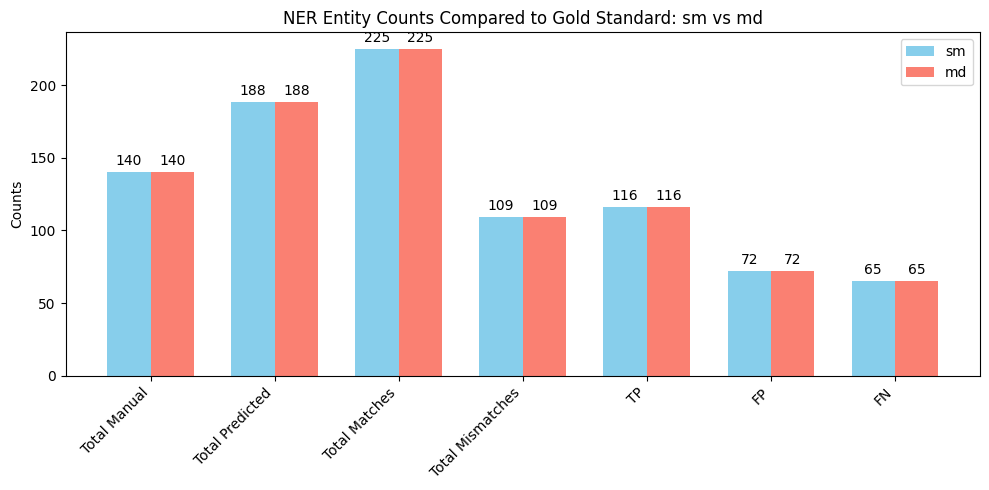

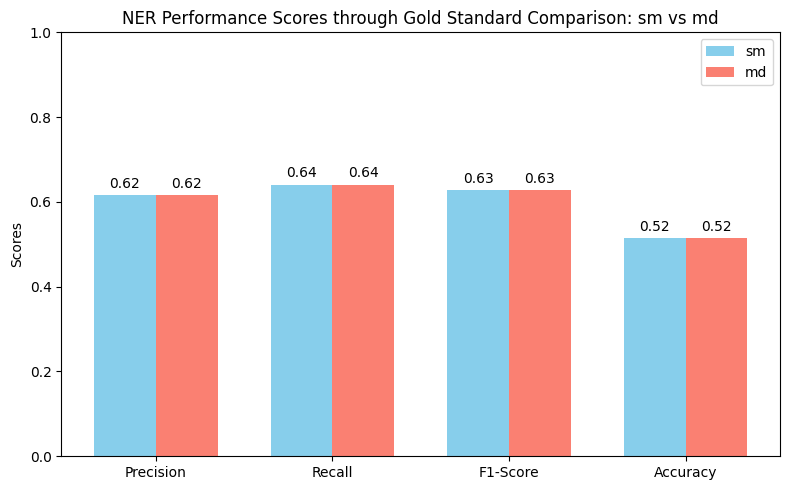

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- Counts chart ---
count_metrics = ['Total Manual', 'Total Predicted', 'Total Matches', 'Total Mismatches', 'TP', 'FP', 'FN']
sm_counts = [140, 188, 225, 109, 116, 72, 65]
md_counts = [140, 188, 225, 109, 116, 72, 65]

x = np.arange(len(count_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))
rects1 = ax.bar(x - width/2, sm_counts, width, label='sm', color='skyblue')
rects2 = ax.bar(x + width/2, md_counts, width, label='md', color='salmon')

ax.set_ylabel('Counts')
ax.set_title('NER Entity Counts Compared to Gold Standard: sm vs md')
ax.set_xticks(x)
ax.set_xticklabels(count_metrics, rotation=45, ha='right')
ax.legend()

def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)
plt.tight_layout()
plt.show()


# --- Scores chart ---
score_metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
sm_scores = [0.6170, 0.6409, 0.6287, 0.5156]
md_scores = [0.6170, 0.6409, 0.6287, 0.5156]

x = np.arange(len(score_metrics))

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, sm_scores, width, label='sm', color='skyblue')
rects2 = ax.bar(x + width/2, md_scores, width, label='md', color='salmon')

ax.set_ylabel('Scores')
ax.set_title('NER Performance Scores through Gold Standard Comparison: sm vs md')
ax.set_xticks(x)
ax.set_xticklabels(score_metrics)
ax.set_ylim(0,1)
ax.legend()

def add_score_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

add_score_labels(rects1)
add_score_labels(rects2)
plt.tight_layout()
plt.show()